In [1]:
import glob
import logging
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
# ── configure logging (optional — mopsf uses the standard logging module) ────
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)

# ── import mopsf modules ──────────────────────────────────────────────────────
from mopsf.psf_model import build_psf_cache
from mopsf.inject    import make_mock_exposures
from mopsf.pipeline  import run_pipeline
from mopsf.measure   import build_epsf, find_mosaic

12:47:49  INFO  Note: detected 192 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
12:47:49  INFO  Note: NumExpr detected 192 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
12:47:49  INFO  NumExpr defaulting to 16 threads.
12:47:52  WARNING  **WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [2]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CONFIGURATION — edit these paths and settings
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

MAIN_DIR    = "/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/"
FILTER      = "F115W"
MPSF_DIR    = MAIN_DIR + f'mpsf/{FILTER}'
PIXEL_SCALE = 0.031    # arcsec/px — LW: 0.063, SW: 0.031

# Input: real Stage 3 cal.fits files
CAL_FILES = sorted(glob.glob(os.path.join(MAIN_DIR, f"direct_image_{FILTER}", "stage3", f"*_a3001_crf.fits")))
print(len(CAL_FILES), CAL_FILES)
# Output dirs (created automatically)
# The mock cal.fits go directly into Resampling.
INJECTED_DIR = os.path.join(MPSF_DIR, "mpsf_injected")
STAGE3_DIR   = os.path.join(MPSF_DIR, "mpsf_stage3")
MOSAIC_DIR   = os.path.join(MPSF_DIR, "mpsf_mosaic")
OUTPUT_DIR   = os.path.join(MPSF_DIR, "mpsf_output")

# Pipeline inputs (same as real-data run)
LW_DIR   = os.path.join(MPSF_DIR, "lw")
ASN_DIR  = os.path.join(MPSF_DIR, "asn")
WISP_DIR = os.path.join(MPSF_DIR, "wisp_templates")
PIXFRAC  = 0.75   # must match real-data resample

384 ['/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca1_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca2_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca3_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrca4_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrcb1_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrcb2_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nrcb3_a3001_crf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/direct_image_F115W/stage3/jw01243001001_02101_00001_nr

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 1 — build stpsf PSFs and inject into mock cal.fits
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n{'='*60}")
print(f"  STEP 1 — PSF model + injection  [{FILTER}]")
print(f"{'='*60}\n")

# Build one PSF per unique detector found in the cal.fits headers
# (cached so stpsf is only called once per detector)
psf_cache = build_psf_cache(
    filter_name = FILTER,
    cal_files   = CAL_FILES,
    pixel_scale = PIXEL_SCALE,
    add_ipc     = True,   
    fov_pixels  = 71,
)

# Inject into mock exposures
mock_files = make_mock_exposures(
    cal_files   = CAL_FILES,
    psf_cache   = psf_cache,
    filter_name = FILTER,
    out_dir     = INJECTED_DIR,
    peak_counts = 1000.0,
)
print(f"\nInjected {len(mock_files)} mock exposures → {INJECTED_DIR}\n")


  STEP 1 — PSF model + injection  [F115W]



10:59:34  INFO  NIRCam aperture name updated to NRCA1_FULL
10:59:34  INFO  stpsf: filter=F115W  detector=NRCA1  pixel_scale=0.0310  IPC=True
10:59:34  INFO  No source spectrum supplied, therefore defaulting to 5700 K blackbody
10:59:34  INFO  Computing wavelength weights using synthetic photometry for F115W...
10:59:34  INFO  PSF calc using fov_pixels = 71, oversample = 4, number of wavelengths = 21
10:59:34  INFO  Creating optical system model:
10:59:34  INFO  Initialized OpticalSystem: JWST+NIRCam
10:59:34  INFO  JWST Entrance Pupil: Loaded amplitude transmission from /home/zhanghan/data/stpsf-data/jwst_pupil_RevW_npix1024.fits.gz
10:59:34  INFO  JWST Entrance Pupil: Loaded OPD from /home/zhanghan/data/stpsf-data/JWST_OTE_OPD_cycle1_example_2022-07-30.fits
10:59:34  INFO  Loading field dependent model parameters from /home/zhanghan/data/stpsf-data/NIRCam/OPD/field_dep_table_nircam.fits
10:59:34  INFO  Calculating field-dependent OTE OPD at v2 = 2.010 arcmin, v3 = -8.792 arcmin
10:59:


Injected 384 mock exposures → /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected



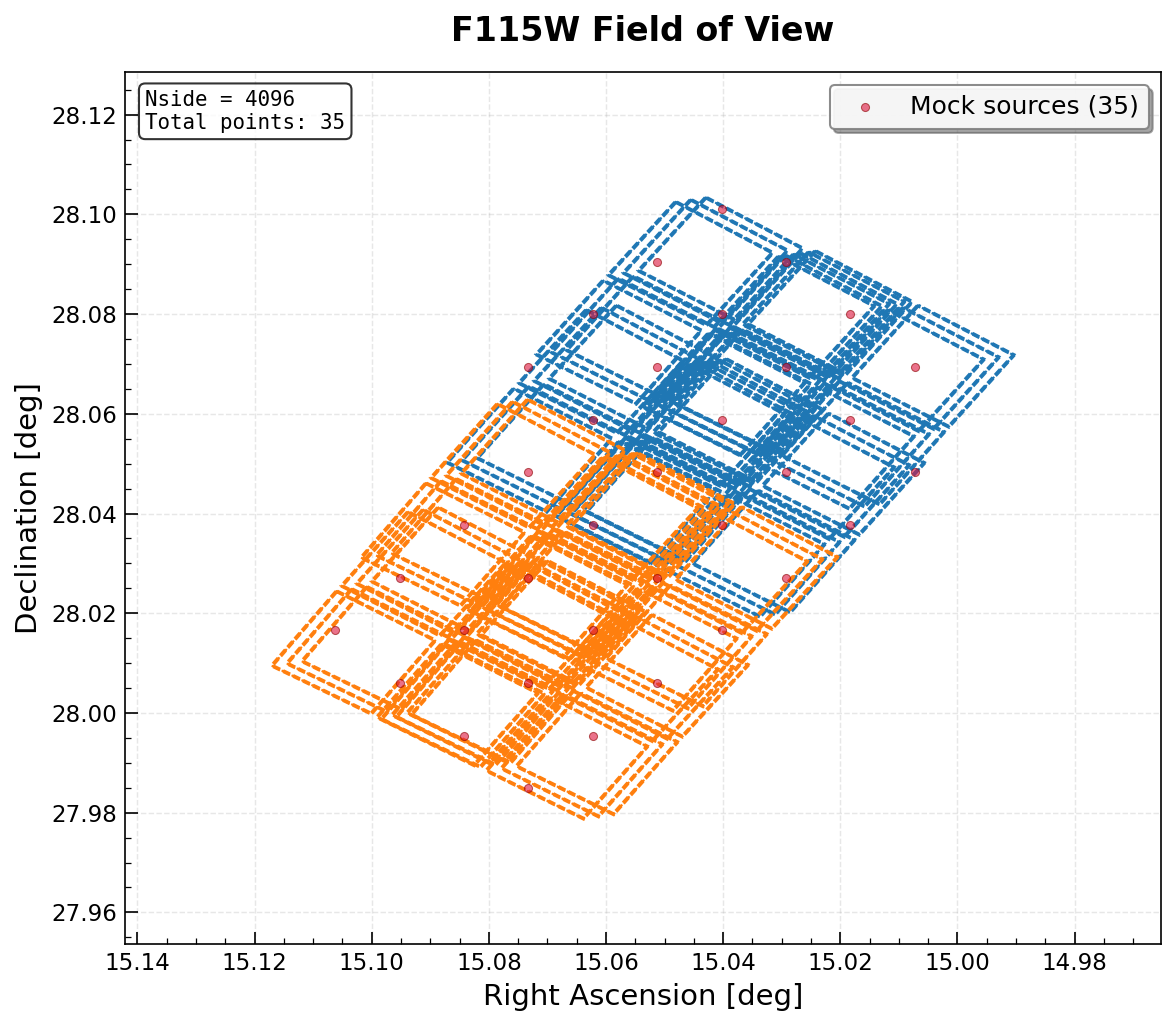

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Visualize the footprint of mock stars
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from astropy.io import fits
import healpy as hp
import matplotlib.patches as patches
from matplotlib.path import Path
from astropy import wcs
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['figure.dpi'] = 150

nside = 2**12   # ~6 injection sites per NIRCam module
npix  = hp.nside2npix(nside)
ipix  = np.arange(npix)
theta, phi = hp.pix2ang(nside, ipix, lonlat=False)
dec_hp = 90.0 - np.degrees(theta)
ra_hp  = np.degrees(phi)

# coordinates in Science frame
sci_x = np.array([0, 2047, 2047, 0])
sci_y = np.array([0, 0, 2047, 2047])

fig, ax = plt.subplots(1, 1, figsize=(8, 7))
module_colors = {'A': '#1f77b4', 'B': '#ff7f0e'}
module_labels = {'A': 'Module A', 'B': 'Module B'}


for i, tmp_cal_path in enumerate(CAL_FILES):
    tmp_module = fits.getheader(tmp_cal_path)['module']
    tmp_color = module_colors[tmp_module]
    
    tmp_grism_hd_sci = fits.getheader(tmp_cal_path, 'sci')
    tmp_grism_hd_wcs = wcs.WCS(tmp_grism_hd_sci)
    coords_corners = wcs.utils.pixel_to_skycoord(sci_x, sci_y, tmp_grism_hd_wcs)
    coords_corners = np.array([coords_corners.ra.value, coords_corners.dec.value]).T

    # Plot polygons with nicer styling
    line_fullcov = patches.Polygon(
        coords_corners, 
        facecolor='none', 
        edgecolor=tmp_color, 
        linewidth=1.0,
        linestyle='--',
        closed=True
    )
    ax.add_patch(line_fullcov)
    #ax.scatter(coords_corners[:, 0], coords_corners[:, 1], 
    #          color=tmp_color, s=30, zorder=5, edgecolors='white', linewidth=1)
    if i == 0: 
        all_corners = coords_corners
    else: 
        all_corners = np.vstack((all_corners, coords_corners))

from scipy.spatial import ConvexHull
hull = ConvexHull(all_corners)
footprint_corners = all_corners[hull.vertices]
footprint_path = Path(footprint_corners)
points = np.column_stack((ra_hp, dec_hp))
mask_inside = footprint_path.contains_points(points)

ra_hp_filtered = ra_hp[mask_inside]
dec_hp_filtered = dec_hp[mask_inside]

xmin = np.max(all_corners[:,0]) + 1.5/60
xmax = np.min(all_corners[:,0]) - 1.5/60
ymin = np.min(all_corners[:,1]) - 1.5/60
ymax = np.max(all_corners[:,1]) + 1.5/60
ax.scatter(ra_hp_filtered, dec_hp_filtered, 
          marker='o', 
          color='crimson', 
          s=15,  # Smaller, more elegant size
          alpha=0.6,
          edgecolors='darkred',
          linewidth=0.5,
          zorder=3,
          label=f'Mock sources ({len(ra_hp_filtered)})')

ax.set(xlim=(xmin, xmax),
       ylim=(ymin, ymax),
       xlabel='Right Ascension [deg]',
       ylabel='Declination [deg]')
ax.set_title(f'{FILTER} Field of View', fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)  # Put grid behind other elements
ax.legend(loc='upper right', framealpha=0.9, edgecolor='gray', fancybox=True, shadow=True)
ax.text(0.02, 0.98, f'Nside = {nside}\nTotal points: {len(ra_hp_filtered)}', 
        transform=ax.transAxes, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
        fontsize=10, family='monospace')
ax.tick_params(axis='both', which='major', labelsize=11, direction='in', length=6)
ax.tick_params(axis='both', which='minor', labelsize=9, direction='in', length=3)
ax.minorticks_on()
plt.tight_layout()

# Save if desired (uncomment to save)
# plt.savefig(f'{FILTER}_FOV.png', dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

8


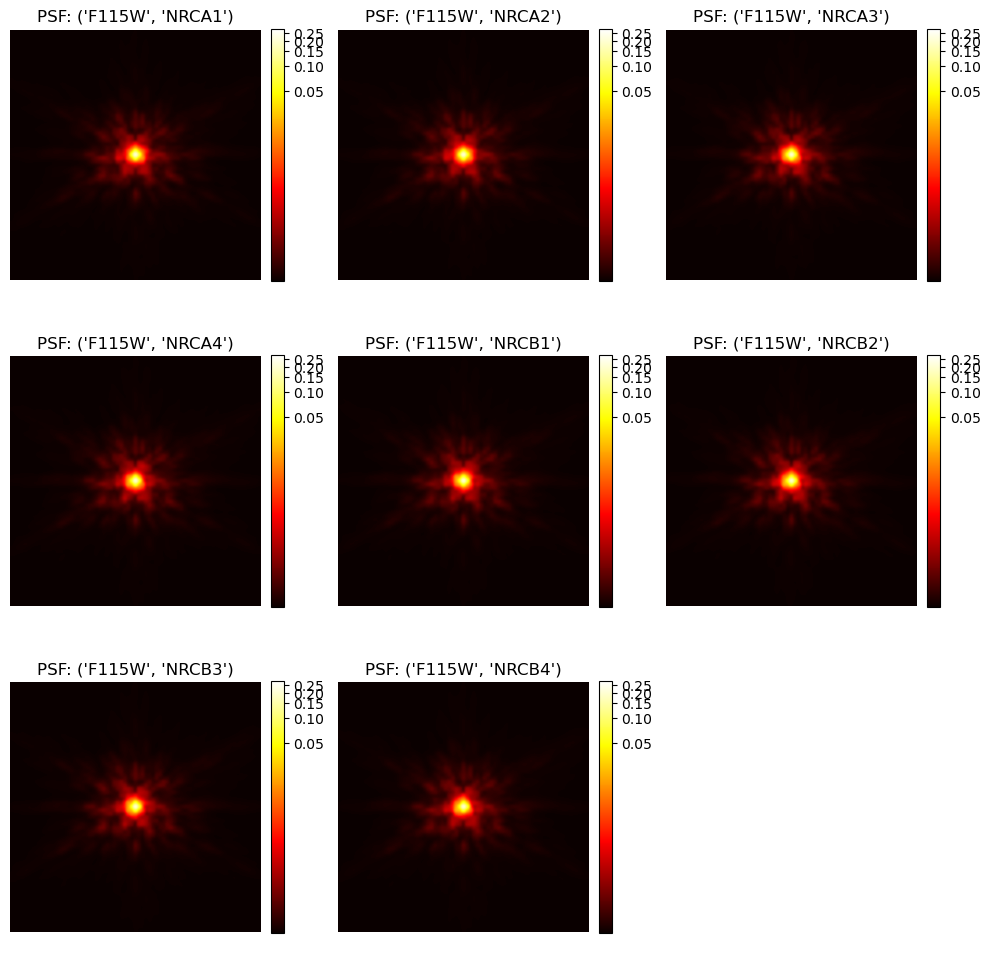

In [20]:
%matplotlib inline
print(len(psf_cache))
nrow = int(np.ceil(len(psf_cache)/3))
fig, axs = plt.subplots(nrow, 3, figsize=(12, 4*nrow))
axs = axs.flatten()
norm = None
for ax in axs:
    ax.axis('off')
for i, key in enumerate(psf_cache):
    psf = psf_cache[key]
    if norm is None:
        norm = simple_norm(psf, stretch='log')
    im = axs[i].imshow(psf, cmap='hot', norm=norm, interpolation='gaussian', origin='lower')
    axs[i].set_title(f"PSF: {key}")
    plt.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)
plt.show()

In [14]:
from photutils.psf import fit_fwhm
print("="*60)
for i, key in enumerate(psf_cache):
    psf = psf_cache[key]
    print(f"FWHM for {key}")
    print(f"pixel scale = {PIXEL_SCALE} arcsec/pixel")
    fwhm_stacked_psfex = fit_fwhm(psf)[0] * PIXEL_SCALE
    print(f"PSF FWHM = {fwhm_stacked_psfex} arcsec")

FWHM for ('F115W', 'NRCA1')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.03953482795530116 arcsec
FWHM for ('F115W', 'NRCA2')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.03953919769763845 arcsec
FWHM for ('F115W', 'NRCA3')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.040064802659142085 arcsec
FWHM for ('F115W', 'NRCA4')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.039797219684001205 arcsec
FWHM for ('F115W', 'NRCB1')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.039666882287224536 arcsec
FWHM for ('F115W', 'NRCB2')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.039871085686866634 arcsec
FWHM for ('F115W', 'NRCB3')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.0399171635907904 arcsec
FWHM for ('F115W', 'NRCB4')
pixel scale = 0.031 arcsec/pixel
PSF FWHM = 0.039964501445113494 arcsec


In [4]:
mock_files = np.sort(glob.glob(os.path.join(INJECTED_DIR, f"*mpsf.fits")))
print(len(mock_files), mock_files)

384 ['/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrca1_a3001_crf_mpsf.fits'
 '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrca2_a3001_crf_mpsf.fits'
 '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrca3_a3001_crf_mpsf.fits'
 '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrca4_a3001_crf_mpsf.fits'
 '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrcb1_a3001_crf_mpsf.fits'
 '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrcb2_a3001_crf_mpsf.fits'
 '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/jw01243001001_02101_00001_nrcb3_a3001_crf_mpsf.fits'
 '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_injected/j

In [5]:
from pathlib import Path
staged_cal_dir = Path(MOSAIC_DIR) / "staged_cal"
in_suffix = "a3001_crf_mpsf"
files = sorted(glob.glob("{0}/*{1}.fits".format(staged_cal_dir, in_suffix)))
print(len(files), files)

384 ['/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrca1_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrca2_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrca3_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrca4_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrcb1_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrcb2_a3001_crf_mpsf.fits', '/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal/jw01243001001_02101_00001_nrcb3_a3001_crf_mpsf.fits', '/mnt/data/JWST

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 2 — run the mosaicing pipeline on mock exposures
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n{'='*60}")
print(f"  STEP 2 — mosaicing pipeline  [{FILTER}]")
print(f"{'='*60}\n")

run_pipeline(
    mock_files  = mock_files,
    filter_name = FILTER.replace("F", "").lstrip("0"),  
    lw_dir      = LW_DIR,
    asn_dir     = ASN_DIR,
    wisp_dir    = WISP_DIR,
    stage3_dir  = STAGE3_DIR,
    mosaic_dir  = MOSAIC_DIR,
    pixfrac     = PIXFRAC
)
print(f"\nMock mosaic written to {MOSAIC_DIR}\n")


  STEP 2 — mosaicing pipeline  [F115W]



13:03:45  INFO  Staged 384 mock cal.fits → /mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/mpsf_mosaic/staged_cal
13:03:45  INFO  Resample (drizzle) with pixfrac=0.75 …
13:03:49  INFO  PARS-RESAMPLESTEP parameters found: /home/zhanghan/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
2026-07-05 13:03:49,851 - stpipe - INFO - PARS-RESAMPLESTEP parameters found: /home/zhanghan/crds_cache/references/jwst/nircam/jwst_nircam_pars-resamplestep_0001.asdf
13:03:49  INFO  ResampleStep instance created.
2026-07-05 13:03:49,863 - stpipe.resample - INFO - ResampleStep instance created.
13:03:49  INFO  Step resample running with args ('/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/asn/nircam_F115W_mosaic.json',).
2026-07-05 13:03:49,988 - stpipe.resample - INFO - Step resample running with args ('/mnt/data/JWST/WFSS/J0100-15157/direct_image_EIGER/mpsf/F115W/asn/nircam_F115W_mosaic.json',).
13:03:49  INFO  Step resample parameters are:
  pre_hoo

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# STEP 3 — measure the effective mosaic PSF (mPSF)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print(f"\n{'='*60}")
print(f"  STEP 3 — ePSF measurement  [{FILTER}]")
print(f"{'='*60}\n")

mosaic_path = find_mosaic(MOSAIC_DIR, FILTER)

os.makedirs(OUTPUT_DIR, exist_ok=True)
epsf_path  = os.path.join(OUTPUT_DIR, f"{FILTER}_mpsf.fits")
stars_path = os.path.join(OUTPUT_DIR, f"{FILTER}_mpsf_stars.fits")

epsf, fitted_stars, stars_tbl = build_epsf(
    mosaic_path  = mosaic_path,
    filter_name  = FILTER,
    cutout_size  = 65,
    oversampling = 4,
    max_iters    = 10,
    min_flux_frac= 0.5,
    save_path    = epsf_path,
    save_stars   = stars_path,
)

print(f"\nmPSF shape : {epsf.data.shape}")
print(f"Stars used : {len(stars_tbl)}")
print(f"ePSF saved → {epsf_path}")
print(f"Stars saved→ {stars_path}")
print("\nDone.")